# 04 — Feature Engineering
**Projet :** Heatwave-ML




## Partie 1 — Chargement des bibliothèques

In [2]:

# Partie 1 — Imports & Configuration

!pip install imbalanced-learn --quiet

from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings, joblib
warnings.filterwarnings('ignore')

from sklearn.preprocessing        import LabelEncoder, StandardScaler
from imblearn.over_sampling       import SMOTE

drive.mount('/content/drive')
PROJECT_ROOT = '/content/drive/MyDrive/heatwave-ml'
os.chdir(PROJECT_ROOT)

for folder in ['models', 'figures', 'data/processed', 'data/splits']:
    os.makedirs(folder, exist_ok=True)

sns.set_theme(style='darkgrid', palette='viridis')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Setup terminé')

Mounted at /content/drive
Setup terminé


In [3]:
# Partie 2 — Chargement

df = pd.read_parquet('data/processed/heatwave_final.parquet')

print("=" * 50)
print("CHARGEMENT")
print("=" * 50)
print(f"Shape    : {df.shape}")
print(f"Colonnes : {list(df.columns)}")
print(f"Période  : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Canicules: {df['is_heatwave'].sum():,} ({df['is_heatwave'].mean()*100:.2f}%)")


CHARGEMENT
Shape    : (343579, 15)
Colonnes : ['Region', 'Country', 'AvgTemperature_C', 'date', 'City_clean', 'temp_max', 'temp_min', 'temp_mean', 'heat_index', 'humidity', 'precip_mm', 'wind_kph', 'Year', 'Month', 'is_heatwave']
Période  : 2009-12-31 → 2020-05-13
Canicules: 17,712 (5.16%)


In [4]:
# Partie 3 — Feature Engineering

print("\n" + "=" * 50)
print("FEATURE ENGINEERING")
print("=" * 50)

# Tri chronologique par ville (obligatoire pour les lags)
df = df.sort_values(['City_clean', 'date']).reset_index(drop=True)
print(" Tri chronologique effectué")

# Feature 1 : Amplitude thermique
df['temp_range'] = df['temp_max'] - df['temp_min']
print(f" temp_range — moyenne : {df['temp_range'].mean():.2f}°C")

# Features 2,3,4 : Lags température max (J-1, J-2, J-3)
df['temp_max_lag1'] = df.groupby('City_clean')['temp_max'].shift(1)
df['temp_max_lag2'] = df.groupby('City_clean')['temp_max'].shift(2)
df['temp_max_lag3'] = df.groupby('City_clean')['temp_max'].shift(3)
print(" Lags 1, 2, 3 créés")

# Feature 5 : Moyenne mobile 7 jours (sans fuite)
df['temp_max_roll7'] = df.groupby('City_clean')['temp_max'].transform(
    lambda x: x.shift(1).rolling(7, min_periods=1).mean()
)
print(" Moyenne mobile 7j créée")

# Feature 6 : Cible régression — temp_max J+3
df['temp_max_J3'] = df.groupby('City_clean')['temp_max'].shift(-3)
print(" temp_max_J3 créée (cible régression)")

# Features temporelles
df['day_of_year'] = df['date'].dt.dayofyear
df['month']       = df['date'].dt.month
df['season']      = df['month'].map({
    12:0, 1:0, 2:0,
    3:1,  4:1, 5:1,
    6:2,  7:2, 8:2,
    9:3, 10:3, 11:3
})
print(" Features temporelles créées (day_of_year, month, season)")


FEATURE ENGINEERING
 Tri chronologique effectué
 temp_range — moyenne : 8.07°C
 Lags 1, 2, 3 créés
 Moyenne mobile 7j créée
 temp_max_J3 créée (cible régression)
 Features temporelles créées (day_of_year, month, season)


In [5]:
# Vérification NaN
print(f"\nNaN après feature engineering :")
cols_check = ['temp_max_lag1','temp_max_lag2','temp_max_lag3',
              'temp_max_roll7', 'temp_max_J3']
print(df[cols_check].isnull().sum())


NaN après feature engineering :
temp_max_lag1     101
temp_max_lag2     201
temp_max_lag3     301
temp_max_roll7    101
temp_max_J3       301
dtype: int64


In [6]:
# Suppression des NaN
lignes_avant = len(df)
df = df.dropna(subset=cols_check)
print(f"\nLignes supprimées (NaN) : {lignes_avant - len(df):,}")
print(f"Shape après dropna      : {df.shape}")


Lignes supprimées (NaN) : 601
Shape après dropna      : (342978, 24)


In [7]:
# Partie 4 — Encodage
print("\n" + "=" * 50)
print("ENCODAGE")
print("=" * 50)

le_region = LabelEncoder()
df['Region_encoded'] = le_region.fit_transform(df['Region'])
print("Régions encodées :")
for i, r in enumerate(le_region.classes_):
    print(f"   {r} → {i}")

le_city = LabelEncoder()
df['City_encoded'] = le_city.fit_transform(df['City_clean'])
print(f"\n {df['City_clean'].nunique()} villes encodées")

# Mapping région pour metadata
region_map = {r: int(i) for i, r in enumerate(le_region.classes_)}

# Sauvegarde encodeurs
joblib.dump(le_region, 'models/le_region.pkl')
joblib.dump(le_city,   'models/le_city.pkl')
print("Encodeurs sauvegardés")



ENCODAGE
Régions encodées :
   Africa → 0
   Asia → 1
   Australia/South Pacific → 2
   Europe → 3
   Middle East → 4
   North America → 5
   South/Central America & Carribean → 6

 100 villes encodées
Encodeurs sauvegardés


In [8]:

# Partie 5 — Définition des features et cibles


print("\n" + "=" * 50)
print("SÉLECTION DES FEATURES")
print("=" * 50)

FEATURES = [
    'temp_max_lag1', 'temp_max_lag2', 'temp_max_lag3',  # Lags
    'temp_max_roll7',                                     # Tendance
    'temp_range',                                         # Amplitude
    'humidity', 'wind_kph', 'precip_mm',                 # Météo brute
    'day_of_year', 'month', 'season',                    # Temporelles
    'Region_encoded', 'City_encoded'                     # Géographie
]

TARGET_CLF = 'is_heatwave'
TARGET_REG = 'temp_max_J3'

COLONNES_SUPPRIMEES = [
    'temp_mean',        # corrélation 0.98 avec temp_max
    'heat_index',       # corrélation 0.98 avec temp_max
    'AvgTemperature_C', # corrélation 0.95 avec temp_max
    'temp_min',         # remplacé par temp_range
    'Country',          # redondant avec Region + City
]

print(f"Features ({len(FEATURES)}) :")
for f in FEATURES:
    print(f"   - {f}")
print(f"\nCibles : {TARGET_CLF} | {TARGET_REG}")
print(f"Colonnes supprimées : {COLONNES_SUPPRIMEES}")

X        = df[FEATURES]
y_clf    = df[TARGET_CLF]
y_reg    = df[TARGET_REG]

print(f"\nShape X    : {X.shape}")
print(f"Canicules  : {y_clf.sum():,} ({y_clf.mean()*100:.2f}%)")


SÉLECTION DES FEATURES
Features (13) :
   - temp_max_lag1
   - temp_max_lag2
   - temp_max_lag3
   - temp_max_roll7
   - temp_range
   - humidity
   - wind_kph
   - precip_mm
   - day_of_year
   - month
   - season
   - Region_encoded
   - City_encoded

Cibles : is_heatwave | temp_max_J3
Colonnes supprimées : ['temp_mean', 'heat_index', 'AvgTemperature_C', 'temp_min', 'Country']

Shape X    : (342978, 13)
Canicules  : 17,678 (5.15%)


In [9]:
# Partie 6 — Split temporel train / val / test

print("\n" + "=" * 50)
print("SPLIT TEMPOREL")
print("=" * 50)

# Split temporel — pas de mélange futur/passé
train_mask = df['date'] < '2018-01-01'
val_mask   = (df['date'] >= '2018-01-01') & (df['date'] < '2019-01-01')
test_mask  = df['date'] >= '2019-01-01'

X_train, y_clf_train, y_reg_train = X[train_mask], y_clf[train_mask], y_reg[train_mask]
X_val,   y_clf_val,   y_reg_val   = X[val_mask],   y_clf[val_mask],   y_reg[val_mask]
X_test,  y_clf_test,  y_reg_test  = X[test_mask],  y_clf[test_mask],  y_reg[test_mask]

print(f"Train  : {X_train.shape} | canicules : {y_clf_train.sum():,} ({y_clf_train.mean()*100:.2f}%)")
print(f"Val    : {X_val.shape}   | canicules : {y_clf_val.sum():,} ({y_clf_val.mean()*100:.2f}%)")
print(f"Test   : {X_test.shape}  | canicules : {y_clf_test.sum():,} ({y_clf_test.mean()*100:.2f}%)")
print(f"\nTrain : 2010→2017 | Val : 2018 | Test : 2019→2020")



SPLIT TEMPOREL
Train  : (269083, 13) | canicules : 13,822 (5.14%)
Val    : (31595, 13)   | canicules : 1,641 (5.19%)
Test   : (42300, 13)  | canicules : 2,215 (5.24%)

Train : 2010→2017 | Val : 2018 | Test : 2019→2020


In [10]:
# Partie 7 — Normalisation


print("\n" + "=" * 50)
print("NORMALISATION")
print("=" * 50)

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit UNIQUEMENT sur train
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("✅ StandardScaler appliqué")
print("⚠️  fit_transform sur X_train uniquement → pas de data leakage")
print(f"Moyenne X_train après scaling : {X_train_scaled.mean():.4f} (≈0)")
print(f"Std X_train après scaling     : {X_train_scaled.std():.4f}  (≈1)")

joblib.dump(scaler, 'models/scaler.pkl')
print("✅ Scaler sauvegardé")


NORMALISATION
✅ StandardScaler appliqué
⚠️  fit_transform sur X_train uniquement → pas de data leakage
Moyenne X_train après scaling : 0.0000 (≈0)
Std X_train après scaling     : 1.0000  (≈1)
✅ Scaler sauvegardé


In [11]:
# Partie 8 — Gestion du déséquilibre (SMOTE)


print("\n" + "=" * 50)
print("SMOTE — RÉÉQUILIBRAGE")
print("=" * 50)

scale_pos_weight = (y_clf_train == 0).sum() / (y_clf_train == 1).sum()

print(f"Avant SMOTE :")
print(f"   Classe 0 : {(y_clf_train==0).sum():,}")
print(f"   Classe 1 : {(y_clf_train==1).sum():,}")
print(f"   Ratio    : 1:{int(scale_pos_weight)}")

sm = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_res, y_clf_train_res = sm.fit_resample(X_train_scaled, y_clf_train)

print(f"\nAprès SMOTE :")
print(f"   Classe 0 : {(y_clf_train_res==0).sum():,}")
print(f"   Classe 1 : {(y_clf_train_res==1).sum():,}")
print(f"   Ratio    : 1:1 ✅")
print(f"   Shape    : {X_train_res.shape}")



SMOTE — RÉÉQUILIBRAGE
Avant SMOTE :
   Classe 0 : 255,261
   Classe 1 : 13,822
   Ratio    : 1:18

Après SMOTE :
   Classe 0 : 255,261
   Classe 1 : 255,261
   Ratio    : 1:1 ✅
   Shape    : (510522, 13)


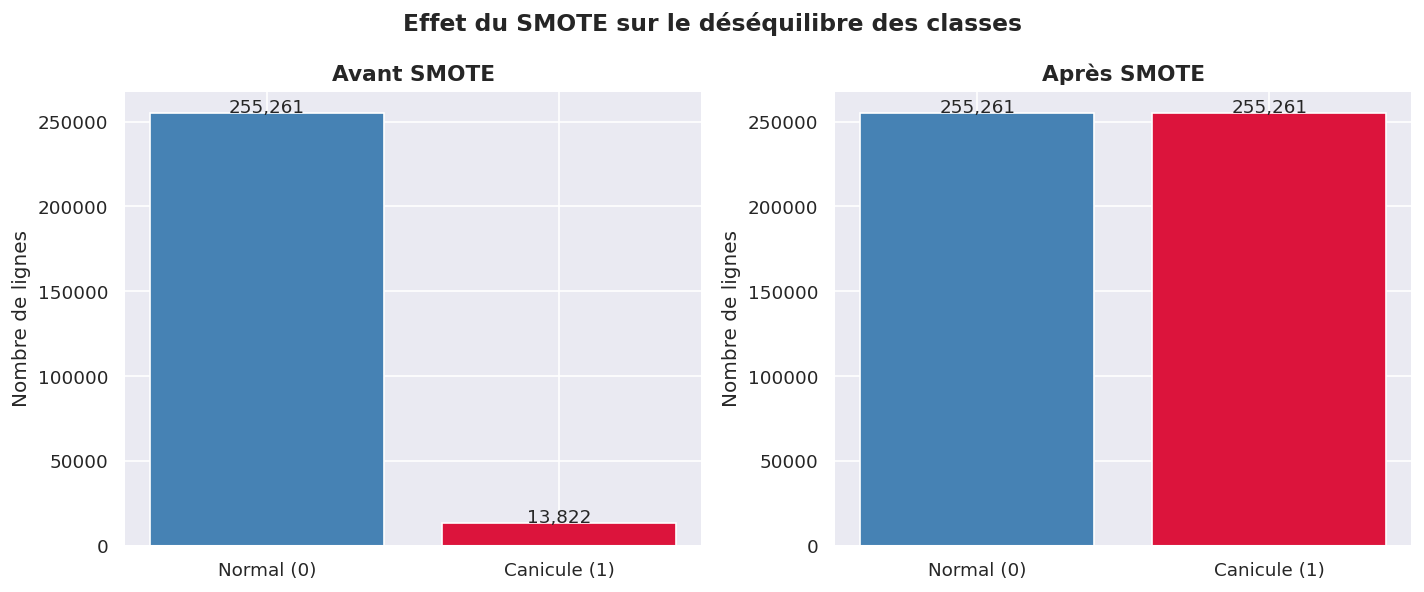

In [12]:
# Partie 9 — Visualisation SMOTE

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['Normal (0)', 'Canicule (1)'],
            [(y_clf_train==0).sum(), (y_clf_train==1).sum()],
            color=['steelblue', 'crimson'])
axes[0].set_title('Avant SMOTE', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nombre de lignes')
for i, v in enumerate([(y_clf_train==0).sum(), (y_clf_train==1).sum()]):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=11)

axes[1].bar(['Normal (0)', 'Canicule (1)'],
            [(y_clf_train_res==0).sum(), (y_clf_train_res==1).sum()],
            color=['steelblue', 'crimson'])
axes[1].set_title('Après SMOTE', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Nombre de lignes')
for i, v in enumerate([(y_clf_train_res==0).sum(), (y_clf_train_res==1).sum()]):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontsize=11)

plt.suptitle('Effet du SMOTE sur le déséquilibre des classes',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/11_smote_balance.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Partie 10 — Sauvegarde

print("=" * 50)
print("SAUVEGARDE")
print("=" * 50)

# Dataset enrichi complet
df.to_parquet('data/processed/heatwave_features.parquet', index=False)

# Splits numpy — classification
np.save('data/splits/X_train.npy',     X_train_res)
np.save('data/splits/X_val.npy',       X_val_scaled)
np.save('data/splits/X_test.npy',      X_test_scaled)
np.save('data/splits/y_clf_train.npy', y_clf_train_res)
np.save('data/splits/y_clf_val.npy',   y_clf_val.values)
np.save('data/splits/y_clf_test.npy',  y_clf_test.values)

# Splits numpy — régression (pas de SMOTE)
np.save('data/splits/y_reg_train.npy', y_reg_train.values)
np.save('data/splits/y_reg_val.npy',   y_reg_val.values)
np.save('data/splits/y_reg_test.npy',  y_reg_test.values)

# Metadata
import json
metadata_fe = {
    'features'        : FEATURES,
    'target_clf'      : TARGET_CLF,
    'target_reg'      : TARGET_REG,
    'scale_pos_weight': float(scale_pos_weight),
    'region_map'      : region_map,
    'split'           : {
        'train': '2010→2017',
        'val'  : '2018',
        'test' : '2019→2020'
    }
}
with open('models/feature_engineering_metadata.json', 'w') as f:
    json.dump(metadata_fe, f, indent=2)

print(" Fichiers sauvegardés :")
print("   data/processed/heatwave_features.parquet")
print("   data/splits/X_train.npy  | y_clf_train.npy | y_reg_train.npy")
print("   data/splits/X_val.npy    | y_clf_val.npy   | y_reg_val.npy")
print("   data/splits/X_test.npy   | y_clf_test.npy  | y_reg_test.npy")
print("   models/scaler.pkl | le_region.pkl | le_city.pkl")
print("   models/feature_engineering_metadata.json")

SAUVEGARDE
 Fichiers sauvegardés :
   data/processed/heatwave_features.parquet
   data/splits/X_train.npy  | y_clf_train.npy | y_reg_train.npy
   data/splits/X_val.npy    | y_clf_val.npy   | y_reg_val.npy
   data/splits/X_test.npy   | y_clf_test.npy  | y_reg_test.npy
   models/scaler.pkl | le_region.pkl | le_city.pkl
   models/feature_engineering_metadata.json


In [14]:

# Partie 11 — Résumé final


print("\n" + "=" * 50)
print("RÉSUMÉ FINAL FEATURE ENGINEERING")
print("=" * 50)
print(f"Features créées      : {len(FEATURES)}")
print(f"Shape X_train (SMOTE): {X_train_res.shape}")
print(f"Shape X_val          : {X_val_scaled.shape}")
print(f"Shape X_test         : {X_test_scaled.shape}")
print(f"Split temporel       : Train 2010-2017 | Val 2018 | Test 2019-2020")
print(f"Déséquilibre         : Corrigé par SMOTE → ratio 1:1")
print(f"scale_pos_weight     : {scale_pos_weight:.1f} (pour XGBoost)")



RÉSUMÉ FINAL FEATURE ENGINEERING
Features créées      : 13
Shape X_train (SMOTE): (510522, 13)
Shape X_val          : (31595, 13)
Shape X_test         : (42300, 13)
Split temporel       : Train 2010-2017 | Val 2018 | Test 2019-2020
Déséquilibre         : Corrigé par SMOTE → ratio 1:1
scale_pos_weight     : 18.5 (pour XGBoost)


In [15]:
# ============================================================
# Dataset final pour le déploiement
# ============================================================

deploy_columns = FEATURES + [
    'date',
    'City_clean',
    'Region',
    'temp_max',
    'temp_min',
    'is_heatwave',
    'temp_max_J3'
]

df_deploy = df[deploy_columns].copy()

df_deploy.to_parquet(
    'data/processed/heatwave_deployment.parquet',
    index=False
)

df_deploy.to_csv(
    'data/processed/heatwave_deployment.csv',
    index=False,
    encoding='utf-8'
)

print("="*60)
print("DATASET FINAL POUR LE DÉPLOIEMENT")
print("="*60)
print(df_deploy.shape)
print(df_deploy.head())

print("\nFichiers créés :")
print("data/processed/heatwave_deployment.parquet")
print("data/processed/heatwave_deployment.csv")

DATASET FINAL POUR LE DÉPLOIEMENT
(342978, 20)
   temp_max_lag1  temp_max_lag2  temp_max_lag3  temp_max_roll7  temp_range  \
3      22.886999      21.587000      23.437000       22.637000    5.850000   
4      21.937000      22.886999      21.587000       22.462000    7.549999   
5      21.737000      21.937000      22.886999       22.317000   10.799998   
6      23.536999      21.737000      21.937000       22.520333    5.050001   
7      23.837000      23.536999      21.737000       22.708428   10.699999   

    humidity   wind_kph  precip_mm  day_of_year  month  season  \
3  71.745125  11.792404        0.0            3      1       0   
4  77.941895  17.373497        0.0            4      1       0   
5  71.594467  21.093050        0.0            5      1       0   
6  70.924217  19.008545        0.0            6      1       0   
7  71.223183  19.829433        0.0            7      1       0   

   Region_encoded  City_encoded       date City_clean       Region   temp_max  \
3     